In [ ]:
try:
    kjghfdhdsfh3
    assert False
except NameError:
    kjghfdhdsfh3 = 3
    pass
import os

In [ ]:
kjghfdhdsfh3 = 3
import os, importlib
import sys, pathlib
import psutil
import threadpoolctl
# Get the current process
import numba
# numba.config.THREADING_LAYER = 'forksafe'

sys.path += ["../diff_co_mpc/"]
workstation = True
# sys.path += [str(pathlib.Path(os.getcwd()) / '..' / "diff_co_mpc")]
if workstation:
    # LD_PRELOAD=<path>/libgomp.so
    # os.environ['LD_PRELOAD'] = '/usr/lib/x86_64-linux-gnu/libmkl_core.so:/usr/lib/x86_64-linux-gnu/libmkl_intel_thread.so:/usr/lib/x86_64-linux-gnu/libmkl_intel_lp64.so:/usr/lib/x86_64-linux-gnu/libiomp5.so:'
    os.environ["OMP_NUM_THREADS"] = "12"  #
    os.environ["MKL_NUM_THREADS"] = "12"  #    
    # os.environ['TORCH_LOGS'] = '+dynamic'
    os.environ["OMP_PLACES"] = "{12:23}"
    os.environ["OMP_PROC_BIND"] = "true"
    os.environ['MKL_THREADING_LAYER'] = 'GNU'
    p = psutil.Process()
    p.cpu_affinity(list(range(12,24)))
else:
    p = psutil.Process()
    # LD_PRELOAD=<path>/libgomp.so
    os.environ["OMP_NUM_THREADS"] = "3"  #
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
    os.environ["TORCHINDUCTOR_COMPILE_THREAD"] = "1"
    # TORCH_LOGS=dynamic
    os.environ['TORCH_LOGS'] = '+dynamic'
    os.environ["OMP_PLACES"] = "{0,2,4}"
    os.environ["OMP_PROC_BIND"] = "true"
    p.cpu_affinity([0,1,2,3,4,5])
import casadi as ca
from IPython.display import clear_output, display, SVG
from functools import partial
from toolz import (
    memoize,
    pipe,
    accumulate,
    groupby,
    compose,
    compose_left,
    merge,
    first,
)
from toolz.curried import do
from collections import namedtuple
import typing as T
import numpy as np
import torch
import itertools
import pathlib, os
from matplotlib import pyplot as plt
import time
import copy
import threadpoolctl

import importlib
from pydrake.all import (
    ModelInstanceIndex,
    RigidTransform,
    RotationMatrix,
    RollPitchYaw,
    StartMeshcat,
)
import threadpoolctl
from utils.my_casadi.misc import time_function, Jit, Compile


from utils.math.BSpline import BSpline

bspline = BSpline(np.array([[0, 0], [0.5, 0.5], [1, 1]]), 3)
bspline.fast_batch_evaluate(np.linspace(0,1,10))
bspline.fast_create_derivative_spline()

import utils.my_casadi.misc as ca_utils
from utils.my_casadi.misc import veccat

# from diff_co_mpc.casadi_custom import *
# from diff_co_mpc.global_planner import *
from mpc.planner_implementation.make import *
from mpc.optimisation_scenario_2 import load_opt_info, DiffCoOptions, make_system
from misc.helper_functions import *

try:
    meshcat
    print("meshcat already defined", meshcat.web_url())
except NameError:
    meshcat = StartMeshcat()
try:
    ROS_INITIALIZED 
except:
    import sys
    sys.path += ["/opt/ros/noetic/lib/python3/dist-packages"]
    import rospy as ros
    ros.init_node('global_planner')
    ROS_INITIALIZED = True
    from actionlib import SimpleActionClient
    from sensor_msgs.msg import JointState
    from trajectory_msgs.msg import JointTrajectory, JointTrajectoryPoint
    from control_msgs.msg import FollowJointTrajectoryAction, \
                                FollowJointTrajectoryGoal, FollowJointTrajectoryResult
TEMP_FOLDER = pathlib.Path(os.getcwd()) / '..' / "temp"
TEMP_FOLDER.mkdir(exist_ok=True)
CODEGEN_FOLDER = TEMP_FOLDER / "codegen"
CODEGEN_FOLDER.mkdir(exist_ok=True, parents=True)
yaml_path = pathlib.Path('..') / 'config'/ "plant_definition.yaml"

system = make_system(yaml_path, meshcat, CODEGEN_FOLDER)
complete_plant = system["complete_plant"]
robots = system["robots"]
viz_helper = system["visualization_helper"]
carried_object = system["carried_object"]
yaml = system["yaml"]

# EE_transform_1 = RigidTransform(
#     p=[0.1, 0, 0], rpy=RollPitchYaw([0, 0, np.pi])
# ).GetAsMatrix4()
# EE_transform_2 = RigidTransform(
#     p=[-0.0, 0, 0], rpy=RollPitchYaw([0, 0, 0])
# ).GetAsMatrix4()


def configuration_to_control_points(configuration, number_of_control_points):
    return np.tile(configuration.reshape(-1,1),(1,number_of_control_points))
def publish_trajectory(opt_data, lcm_subscription_handler, order = 3):
    message = lcmt_global_solve()
    message.utime = time.perf_counter_ns()
    message.bspline_robot_1.control_points = opt_data.result["robot_1_control_points"]
    message.bspline_robot_1.order = order
    message.bspline_robot_2.order = order
    message.bspline_robot_1.num_positions = opt_data.result["robot_1_control_points"].shape[0]
    message.bspline_robot_1.num_control_points = opt_data.result["robot_1_control_points"].shape[1]
    message.bspline_robot_2.control_points = opt_data.result["robot_2_control_points"]
    message.bspline_robot_2.num_positions = opt_data.result["robot_2_control_points"].shape[0]
    message.bspline_robot_2.num_control_points = opt_data.result["robot_2_control_points"].shape[1]
    message.bspline_object.control_points = opt_data.result["carried_object_control_points"]
    message.bspline_object.num_positions = opt_data.result["carried_object_control_points"].shape[0]
    message.bspline_object.num_control_points = opt_data.result["carried_object_control_points"].shape[1]
    lcm_subscription_handler.lcm.Publish("global_trajectory", message.encode())
def display_trajectory(opt_data,meshcat):
    bspline_1_col = BSpline(
        opt_data.result["robot_1_control_points"],
        opt_collision.order,
    )
    bspline_2_col = BSpline(
        opt_data.result["robot_2_control_points"],
        opt_collision.order,
    )
    bspline_obj_col = BSpline(
        opt_data.result["carried_object_control_points"],
        opt_collision.order,
    )
    

    meshcat.StartRecording(frames_per_second=30.0)

    for s in np.linspace(0,1,15):
        q_1 = bspline_1_col.evaluate(s)
        q_1 = np.concatenate([q_1,np.zeros(2)])
        q_2 = bspline_2_col.evaluate(s)
        q_2 = np.concatenate([q_2,np.zeros(2)])
        q_obj = bspline_obj_col.evaluate(s)
        
        viz_helper.set_position('robot_0',q_1)
        viz_helper.set_position('robot_1',q_2)
        viz_helper.set_position('carried_object',q_obj)
        

        viz_helper.diagram_context.SetTime(s)
        
        viz_helper.publish_diagram()

    meshcat.StopRecording()
    
    meshcat.PublishRecording()
def display_initial_guesses(parallel_data_object,show_all = False):
    meshcat.StartRecording(frames_per_second=30.0)
    ii = 0
    bspline_1_col = []
    bspline_2_col = []
    bspline_obj_col = []
    for i in range(parallel_data_object.map_size):
        bspline_1_col.append(BSpline(parallel_data_object.result['robot_1_control_points'][i],opt_collision.order))
        bspline_2_col.append(BSpline(parallel_data_object.result['robot_2_control_points'][i],opt_collision.order))
        bspline_obj_col.append(BSpline(parallel_data_object.result['carried_object_control_points'][i],opt_collision.order))
    for i in range(parallel_data_object.map_size):
        if parallel_data_object.within_bounds()[i] or show_all:
            for s in np.linspace(0,1,80):
                q_1 = bspline_1_col[i].evaluate(s)
                q_2 = bspline_2_col[i].evaluate(s)
                q_obj = bspline_obj_col[i].evaluate(s)
                q_1 = np.concatenate([q_1,np.zeros(2)])
                q_2 = np.concatenate([q_2,np.zeros(2)])
                
                
                viz_helper.set_position('robot_0',q_1)
                viz_helper.set_position('robot_1',q_2)
                viz_helper.set_position('carried_object',q_obj)              

                viz_helper.diagram_context.SetTime(s+ii)
                viz_helper.publish()
            ii+=1
            if parallel_data_object.within_bounds()[i]: print(ii)
    meshcat.StopRecording()
    meshcat.PublishRecording()
def collision_score_from_parallel_solves(num_samples,planner):
    def polyharmonic_kernel(
        x: torch.Tensor, y: torch.Tensor, alpha: int
    ) -> torch.Tensor:

        if alpha % 2 == 1:
            return torch.linalg.norm(x - y, axis=-1) ** alpha
        else:
            r = torch.linalg.norm(x - y, axis=-1)
            temp = (r**alpha) * torch.log(r)
            temp[torch.isnan(temp)] = 0.0

            return temp
    total_scores = {}
    for i in range(planner.parallel_solve_data.map_size):
        bspline_1 = (BSpline(planner.parallel_solve_data.result['robot_1_control_points'][i],opt_collision.order))
        bspline_2 = (BSpline(planner.parallel_solve_data.result['robot_2_control_points'][i],opt_collision.order))
        # bspline_obj_col = (BSpline(planner.parallel_solve_data.result['carried_object_control_points'][i],opt_collision.order))
        total_score = 0
        for s in np.linspace(0,1,num_samples):
            # print(s)
            # text= ''
            for robot in ['robot_1','robot_2']:
                for group_name in ['group_1','group_2','group_3','group_4']:
                    weights = torch.as_tensor(planner.lcm_subscription_handler.last_svm[robot][group_name][-1]['weights'])
                    support_vectors = torch.as_tensor(planner.lcm_subscription_handler.last_svm[robot][group_name][-1]['sv'])
                    polynomial_weights = torch.as_tensor(planner.lcm_subscription_handler.last_svm[robot][group_name][-1]['pol_weights']).squeeze()
                    q = torch.as_tensor(bspline_2.evaluate(s) if robot == 'robot_2' else bspline_1.evaluate(s))
                    col_model = planner.robot_1_collision_model if robot == 'robot_1' else planner.robot_2_collision_model
                    fk_q = col_model.forward_kinematics_groups_torch[group_name](q)
                    sample = fk_q.reshape(-1)
                    dist = polyharmonic_kernel(sample, support_vectors.T, 1)
                    score = torch.dot(weights.reshape(-1).to(torch.float64), dist.reshape(-1).to(torch.float64)) + polynomial_weights[0].reshape(-1).to(torch.float64) + torch.dot(polynomial_weights[1:].reshape(-1).to(torch.float64), sample.reshape(-1).to(torch.float64))
                    total_score += torch.clip(score,torch.tensor(0.),torch.inf)
                    # print(s,score)
                    # text += f'{group_name}: {score.item():.2f} '
                # text+= '\n'
            # print(text)
        total_scores[i] = total_score
    return total_scores
from pydrake.all import Sphere

# path = 'tensors.pth'
# loaded_tensors = torch.load(path)
# # Access the tensors
# obstacle_points = loaded_tensors['tensor1'].numpy()
# obstacle_radii = loaded_tensors['tensor2'].numpy()

# sphere_positions = obstacle_points
from multiprocessing import shared_memory
dtype = np.float32
array_shape = (10000, 3)
shared_memory_name = "point_cloud_shared_memory"

try:
    shm = shared_memory.SharedMemory(name=shared_memory_name, create=True, size=np.prod(array_shape) * np.dtype(dtype).itemsize)
    shared_array = np.ndarray(array_shape, dtype=dtype, buffer=shm.buf)
    shared_array[:] = np.nan
    print("Created new shared memory.")
except FileExistsError:
    shm = shared_memory.SharedMemory(name=shared_memory_name)
    shared_array = np.ndarray(array_shape, dtype=dtype, buffer=shm.buf)
    print("Linked to existing shared memory.")
point_cloud = shared_array.copy()
point_cloud = point_cloud[~np.isnan(point_cloud).any(axis=1)]

point_cloud_size = point_cloud.shape[0]
obstacle_points = torch.as_tensor(point_cloud).to(device = 'cpu',dtype=torch.float32)
obstacle_radii = torch.tensor(0.04, dtype=torch.float32, device='cpu').expand(point_cloud_size, 1).to(device = 'cpu',dtype=torch.float32)
for i, q_sample in enumerate(obstacle_points):
    meshcat.SetObject(
        f"/obstacles/{i}", Sphere(obstacle_radii[i])
    )
    meshcat.SetProperty(
        f"/obstacles/{i}", "position", q_sample.tolist()
    )
class PointCloudViz:
    def __init__(self, meshcat):
        self.meshcat = meshcat
        self.shm = shared_memory.SharedMemory(name=shared_memory_name)
        self.point_cloud = np.ndarray(array_shape, dtype=dtype, buffer=self.shm.buf)

    def update(self):
        point_cloud = self.point_cloud.copy()
        point_cloud = point_cloud[~np.isnan(point_cloud).any(axis=1)]
        obstacle_radii = torch.tensor(0.04, dtype=torch.float32, device='cpu').expand(point_cloud.shape[0], 1).to(device = 'cpu',dtype=torch.float32).numpy()
        for i in range(1000):
            self.meshcat.Delete(f"/obstacles/{i}")
        for i, q_sample in enumerate(point_cloud):
            self.meshcat.SetObject(
                f"/obstacles/{i}", Sphere(obstacle_radii[i])
            )
            self.meshcat.SetProperty(
                f"/obstacles/{i}", "position", q_sample.tolist()
            )
point_cloud_viz = PointCloudViz(meshcat)
point_cloud_viz.update()



In [ ]:
collision_options = {
    "print_time": True,
    "ipopt": {
        "print_level": 3,
        "hessian_approximation": "exact",
        "linear_solver": "ma57",
        "max_iter": 10000,
        # "print_timing_statistics":"yes",
        "constr_viol_tol": 1e-4,
        "tol": 1e-4,
        "acceptable_tol": 1e-2,
        "acceptable_obj_change_tol": 1e-1,
        "max_wall_time": 10.,
        "warm_start_init_point": "yes",
        # 'warm_start_same_structure':'no',
        'warm_start_bound_push'  :     1e-9,
        'warm_start_bound_frac':       1e-9,
        'warm_start_slack_bound_frac': 1e-9,
        'warm_start_slack_bound_push': 1e-9,
        'warm_start_mult_bound_push' : 1e-9,
        'nlp_scaling_method':'none',
        'mu_strategy':'monotone',
        'mu_init':0.001,
        # 'mu_init':0.1,
        'ma57_pre_alloc':3.
        # "fast_step_computation": "yes",
    },
}
collision_options_very_short = {
    "ipopt": {
        "print_level": 0,
        "hessian_approximation": "exact",
        "linear_solver": "ma57",
        "max_iter": 10000,
        # "print_timing_statistics":"yes",
        "constr_viol_tol": 1e-4,
        "tol": 1e-4,
        "acceptable_tol": 1e-2,
        "acceptable_obj_change_tol": 1e-1,
        "max_wall_time": 0.25,
        "warm_start_init_point": "yes",
        # 'warm_start_same_structure':'no',
        'warm_start_bound_push'  :     1e-9,
        'warm_start_bound_frac':       1e-9,
        'warm_start_slack_bound_frac': 1e-9,
        'warm_start_slack_bound_push': 1e-9,
        'warm_start_mult_bound_push' : 1e-9,
        'nlp_scaling_method':'none',
        'mu_strategy':'monotone',
        'mu_init':0.001,
        # 'mu_init':0.1,
        'ma57_pre_alloc':3.
        # "fast_step_computation": "yes",
    },
}

num_samples = 10
num_control_points = 20
order = 3

import importlib
import mpc
import mpc.optimisation_scenario_2
import mpc.planner_implementation.make

importlib.reload(mpc.optimisation_scenario_2)
importlib.reload(mpc.planner_implementation.make)

# from diff_co_mpc.mpc import make_planner_with_collision, make_planner_with_no_collision
from mpc.planner_implementation.make import *
from mpc.optimisation_scenario_2 import *

diff_co_options = DiffCoOptions.from_yaml(pathlib.Path(yaml_path))

gaze_options = None

opt_with_collision_compile_path = CODEGEN_FOLDER / "nlp_scenario_2"
opt_with_collision_compile_path.mkdir(exist_ok=True, parents=True)

rebuild_col = False

if rebuild_col:
    opt_collision = make_planner_with_collision_scenario_2(
        robots,
        carried_object,
        num_samples,
        num_control_points,
        order,
        diff_co_options,
        gaze_options,
        collision_options,
        opt_with_collision_compile_path,
    )
else:
    opt_collision = load_opt_info(
        opt_with_collision_compile_path,
        robots,
        carried_object,
        num_control_points,
        order,
        diff_co_options,
        gaze_options,
        collision_options,
    )
opt_collision_very_short = load_opt_info(
    opt_with_collision_compile_path,
    robots,
    carried_object,
    num_control_points,
    order,
    diff_co_options,
    gaze_options,
    collision_options_very_short,
)


In [ ]:
aaa

In [ ]:
point_cloud_viz.update()

In [ ]:

import threadpoolctl
with threadpoolctl.threadpool_limits(limits=12):
    time_function(opt_collision.nlp_hess_l)
    time_function(opt_collision.nlp_jac_g)
    # time_function(opt_collision.nlp_g)
    # time_function(opt_collision.nlp_f)
    # time_function(opt_collision.nlp_grad_f)

In [ ]:
import mpc.planner_implementation.lcm_handler
import mpc.planner_implementation.ros_handler
import mpc.planner_implementation.helper_scenario_2
import mpc.planner_implementation.helper_mixin
import mpc.helper_functions
importlib.reload(mpc.planner_implementation.lcm_handler)
importlib.reload(mpc.planner_implementation.ros_handler)
importlib.reload(mpc.planner_implementation.helper_mixin)
importlib.reload(mpc.planner_implementation.helper_scenario_2)
importlib.reload(mpc.helper_functions)
from mpc.planner_implementation.helper_scenario_2 import Planner
from mpc.planner_implementation.lcm_handler import VisionParameters
from mpc.planner_implementation.ros_handler import ROSHandler
ros_handler = ROSHandler(None)
lcm_subscription_handler_configuration = VisionParameters(
    sampling_size_around_spot = 1,
    num_samples_spot=1,
    num_samples_gaze=1,
    num_samples_gaze_turn=1,
    q7_guesses=1,
    elevation=1,
    robot_base_pose_1= 1,
    polyharmonic_kernel = None,
    kernel_gaze = None,
)
planner = Planner(opt_collision, 
                  meshcat,
                    lcm_subscription_handler_configuration = lcm_subscription_handler_configuration, 
                    ros_handler = ros_handler, 
                    viz_helper = viz_helper,
                    num_parallel_plans = 12
)
planner.set_plan_grasping_bounds(np.array([0.00,0.1]),np.array([-0.1,-0.00]))
planner.set_costs(vision_cost = 0,
                   duration_cost = 0.001, 
                   acceleration_cost = 0.001, 
                   manipulability_cost = .0001, 
                   replan_connection_cost = 1.,
                   slack_cost_weight = -0.1,
                   end_position_slack_cost_weight = [100.]*4)
planner.set_time_bounds_plan(0.5,20.)
planner.set_velocity_scaling(0.1)
planner.parallel_solve_data.set_initial_guess('duration', np.array(2.))
planner.initial_plan_data.set_initial_guess('duration', np.array(2.))

planner.EE_transform_1 = RigidTransform(
    p=[0.1, 0, 0], rpy=RollPitchYaw([0, 0, 0])
).GetAsMatrix4()
planner.EE_transform_2 = RigidTransform(
    p=[-0.1, 0, 0], rpy=RollPitchYaw([0, 0, np.pi])
).GetAsMatrix4()
planner.initial_pose = np.array([[ 1.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  ,  0.27],
       [-0.  ,  0.  ,  1.  ,  0.25],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])
planner.placing_spot_pose = np.array([[ 1. ,  0. ,  0. ,  0. ],
       [ 0. ,  1. ,  0. , -0.4],
       [-0. ,  0. ,  1. ,  0.2],
       [ 0. ,  0. ,  0. ,  1. ]])
    #         opt_data.set_parameter("object_start_position", self.initial_pose[:3,3:4])
            # 3            # self.slack_lbg = self.parameter("slack_lbg", 1, 1)
            # self.slack_ubg = self.parameter("slack_ubg", 1, 1)
            # self.slack_offset = self.parameter("slack_offset", 1, 1)
for opt_data in [planner.initial_plan_data, planner.parallel_solve_data, planner.replan_data]:
    opt_data.set_parameter("slack_lbg", np.array(-10.))
    opt_data.set_parameter("slack_ubg", np.array(2.))
    opt_data.set_parameter("slack_offset", np.array(-5))

In [ ]:
def set_parallel_initial_guesses(self,num_q7s,initial_pose,end_pose):
    num_initial_guesses = self.parallel_solve_data.map_size
    q1 = self.robot_1_inverse_kinematics.casadi_obj_IK_compiled(initial_pose,np.linspace(-np.pi,np.pi,num_q7s).reshape(1,-1),np.array([0.]*7),self.EE_transform_1)
    q1 = q1.full().reshape(-1,7)
    q1 = q1[~np.isnan(q1).any(axis=1)]

    q2 = self.robot_2_inverse_kinematics.casadi_obj_IK_compiled(initial_pose,np.linspace(-np.pi,np.pi,num_q7s).reshape(1,-1),np.array([0.]*7),self.EE_transform_2)
    q2 = q2.full().reshape(-1,7)
    q2 = q2[~np.isnan(q2).any(axis=1)]
    q1_combinations = q1[np.arange(q1.shape[0]).repeat(q2.shape[0])]
    q2_combinations = q2[np.tile(np.arange(q2.shape[0]),q1.shape[0])]
    indices = np.random.randint(0,q2_combinations.shape[0],num_initial_guesses)
    q_1_start = q1_combinations[indices]
    q_2_start = q2_combinations[indices]
    assert q_1_start.size > 0
    assert q_2_start.size > 0
    obj_start = np.concatenate((RotationMatrix(initial_pose[:3,:3]).ToQuaternion().wxyz(),initial_pose[:3,3]  + np.array([0,0,0.1])))
    obj_end = np.concatenate((RotationMatrix(end_pose[:3,:3]).ToQuaternion().wxyz(),end_pose[:3,3] + np.array([0,0,0.1])))
    self.parallel_solve_data.set_initial_guess('carried_object_control_points', np.linspace(obj_start,obj_end,self.num_control_points_mpc).T)
    for i,(q1,q2) in enumerate(zip(q_1_start,q_2_start)):
        self.parallel_solve_data.set_initial_guess('robot_1_control_points', configuration_to_control_points(q1, self.num_control_points_mpc),i)
        self.parallel_solve_data.set_initial_guess('robot_2_control_points', configuration_to_control_points(q2, self.num_control_points_mpc),i)
planner.set_parallel_initial_guesses = partial(set_parallel_initial_guesses,planner)


planner.initial_pose = np.array([[ 1.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  ,  0.0],
       [-0.  ,  0.  ,  1.  ,  0.6],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])
planner.placing_spot_pose = np.array([[ 1. ,  0. ,  0. ,  0. ],
       [ 0. ,  1. ,  0. , 0.0],
       [-0. ,  0. ,  1. ,  0.6],
       [ 0. ,  0. ,  0. ,  1. ]])

planner.parallel_solve_data.x0[:] = 0.
planner.parallel_solve_data.lam_g0[:] = 0.
planner.parallel_solve_data.lam_x0[:] = 0.
num_q7s = 20
planner.parallel_solve_data.set_initial_guess('duration', np.array(2.))
planner.set_parallel_initial_guesses(num_q7s,planner.initial_pose,planner.placing_spot_pose)
planner.set_collision_bounds(-np.inf,np.inf)


with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
    planner.parallel_plans()
# print('hi')
    # planner.parallel_plans(q_1_start,q_2_start)
    # planner.parallel_plans(q_1_start,q_2_start)

    
planner.set_collision_bounds(-np.inf,0.4)
solved = []
for i in range(planner.parallel_solve_data.map_size):
    if planner.parallel_solve_data.within_bounds()[i]:
        solved.append(i)
not_solved = [i for i in range(planner.parallel_solve_data.map_size) if i not in solved]
for i in not_solved:
    # choose one of the solved indices
    j = np.random.choice(solved)
    noisified_control_points = planner.parallel_solve_data.result['robot_1_control_points'][j] + np.random.normal(0,0.1,planner.parallel_solve_data.result['robot_1_control_points'][j].shape)
    planner.parallel_solve_data.set_initial_guess('robot_1_control_points',noisified_control_points ,i)
    noisified_control_points = planner.parallel_solve_data.result['robot_2_control_points'][j] + np.random.normal(0,0.1,planner.parallel_solve_data.result['robot_2_control_points'][j].shape)
    planner.parallel_solve_data.set_initial_guess('robot_2_control_points',noisified_control_points ,i)
    planner.parallel_solve_data.lam_g0[:,i] = 0.
    planner.parallel_solve_data.lam_x0[:,i] = 0.
with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
    planner.parallel_plans()
# planner.set_collision_bounds(-np.inf,0.2)
# with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
#     planner.parallel_plans()
# planner.set_collision_bounds(-np.inf,0.0)
# with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
#     planner.parallel_plans()
    # planner.parallel_plans()
point_cloud_viz.update()


In [ ]:
point_cloud_viz.update()
i = 0
bspline_1_col = (BSpline(planner.parallel_solve_data.result['robot_1_control_points'][i],opt_collision.order))
bspline_2_col = (BSpline(planner.parallel_solve_data.result['robot_2_control_points'][i],opt_collision.order))
bspline_obj_col = (BSpline(planner.parallel_solve_data.result['carried_object_control_points'][i],opt_collision.order))
# planner.initial_plan_data.x[:] = planner.parallel_solve_data.x[:,i].reshape(-1,1)
display_initial_guesses(planner.parallel_solve_data,True)
# print_collision_score_on_samples(30,planner,bspline_1_col,bspline_2_col)
# publish_trajectory(planner.initial_plan_data, planner.lcm_subscription_handler, order = 3)
# collision_score_from_parallel_solves(30,planner)
print([np.sum(x+y) for x,y in zip(planner.parallel_solve_data.ubg_violation(),planner.parallel_solve_data.lbg_violation())])
# print()
collision_score_from_parallel_solves(30,planner)


In [ ]:
def solve_for_current_obj_position():
    def get_grasping_constraint_function(self):

        q_obj = ca.MX.sym("q_obj", self.carried_object.wrapper.num_positions())
        frame_pose_object_1 = self.carried_object.wrapper.calc_frame_pose_in_frame(
            q_obj,
            self.carried_object_EE_1_frame,
            self.carried_object.plant.world_frame(),
            clean_small_coeffs=1e-6,
        )
        frame_pose_object_2 = self.carried_object.wrapper.calc_frame_pose_in_frame(
            q_obj,
            self.carried_object_EE_2_frame,
            self.carried_object.plant.world_frame(),
            clean_small_coeffs=1e-6,
        )

        q_robot_1 = ca.MX.sym("q_robot_1", self.robots[0].wrapper.num_positions())
        anglebound = ca.MX.sym("anglebound", 1)
        grasping_point_1 = ca.MX.sym("grasping_point", 3)
        grasping_rotation_matrix_1 = ca.MX.sym("grasping_rotation_matrix", 3, 3)
        frame_pose_robot_1 = self.robots[0].wrapper.calc_frame_pose_in_frame(
            q_robot_1,
            self.robot_1_EE_frame,
            self.robots[0].plant.world_frame(),
            clean_small_coeffs=1e-6,
        )
        # frame_1_in_2 = frame_pose_robot_1 @ casadi_4x4_inverse(frame_pose_object_1)
        frame_1 = frame_pose_object_1
        frame_2 = frame_pose_robot_1
        rotation_1 = grasping_rotation_matrix_1
        rotation_2 = ca.DM.eye(3)
        frame_2_in_1 = casadi_frame_A_in_frame_B(frame_2, frame_1)
        g_translation, lbg_translation, ubg_translation = (
            KinematicOptimization.fwd_kin_translation_constraint(
                frame_1, grasping_point_1, frame_2, [0, 0, 0], [0, 0, 0], [0, 0, 0]
            )
        )
        g_orientation, lbg_orientation, ubg_orientation = (
            KinematicOptimization.fwd_kin_orientation_constraint(
                rotation_1, rotation_2, frame_2_in_1, anglebound
            )
        )
        g = ca.veccat(g_translation, g_orientation)
        lbg = ca.veccat(lbg_translation, lbg_orientation)
        ubg = ca.veccat(ubg_translation, ubg_orientation)

        q_robot_2 = ca.MX.sym("q_robot_2", self.robots[1].wrapper.num_positions())
        grasping_point_2 = ca.MX.sym("grasping_point_2", 3)
        grasping_rotation_matrix_2 = ca.MX.sym("grasping_rotation_matrix_2", 3, 3)
        frame_pose_robot_2 = self.robots[1].wrapper.calc_frame_pose_in_frame(
            q_robot_2,
            self.robot_2_EE_frame,
            self.robots[1].plant.world_frame(),
            clean_small_coeffs=1e-6,
        )
        frame_1 = frame_pose_object_2
        frame_2 = frame_pose_robot_2
        rotation_1 = grasping_rotation_matrix_2
        rotation_2 = ca.DM.eye(3)
        frame_2_in_1 = casadi_frame_A_in_frame_B(frame_2, frame_1)
        g_translation, lbg_translation, ubg_translation = (
            KinematicOptimization.fwd_kin_translation_constraint(
                frame_1, grasping_point_2, frame_2, [0, 0, 0], [0, 0, 0], [0, 0, 0]
            )
        )
        g_orientation, lbg_orientation, ubg_orientation = (
            KinematicOptimization.fwd_kin_orientation_constraint(
                rotation_1, rotation_2, frame_2_in_1, anglebound
            )
        )
        g = ca.veccat(g, g_translation, g_orientation)
        lbg = ca.veccat(lbg, lbg_translation, lbg_orientation)
        ubg = ca.veccat(ubg, ubg_translation, ubg_orientation)

        x = ca.veccat(q_obj, q_robot_1, q_robot_2, grasping_point_1, grasping_point_2,anglebound)
        p = ca.veccat(grasping_rotation_matrix_1, grasping_rotation_matrix_2)
        
        g_function = ca.Function(
            "grasping_constraint_function",
            {
                "x": x,
                "p": p,
                "g": g,
            },
            ["x", "p"],
            [
                "g",
            ],
            {
                "post_expand": True,
                "post_expand_options": {
                    "cse": True,
                    "is_diff_in": [True, False],
                    "is_diff_out": [
                        True,
                    ],
                },
            },
        )
        lbg_function = ca.Function(
            "grasping_constraint_function",
            {
                "p": p,
                "lbg": lbg,
            },
            ["p"],
            [
                "lbg",
            ],
        )
        ubg_function = ca.Function(
            "grasping_constraint_function",
            {
                "p": p,
                "ubg": ubg,
            },
            ["p"],
            [
                "ubg",
            ],
        )
        return {"g": g_function, "lbg": lbg_function, "ubg": ubg_function}

    opti = ca.Opti()
    grasping_x_EE_1 = opti.variable( 1, 1)
    grasping_x_EE_2 = opti.variable(1, 1)
    anglebound = opti.variable(1, 1)
    q_robot_1 = opti.parameter(7, 1)
    q_robot_2 = opti.parameter(7, 1)
    q_obj = opti.variable(7, 1)
    grasping_point_EE_1: ca.MX = ca.veccat(grasping_x_EE_1, 0, 0)
    grasping_point_EE_2: ca.MX = ca.veccat(grasping_x_EE_2, 0, 0)
    grasping_rotation_matrix_EE_1: ca.MX = ca.vertcat(
        ca.horzcat(
            ca.cos(0),
            -ca.sin(3.14159265),
            0,
        ),
        ca.horzcat(
            ca.sin(3.14159265),
            ca.cos(3.14159265),
            0,
        ),
        ca.horzcat(0, 0, 1),
    )
    grasping_rotation_matrix_EE_2: ca.MX = ca.vertcat(
        ca.horzcat(
            ca.cos(0),
            -ca.sin(0),
            0,
        ),
        ca.horzcat(
            ca.sin(0),
            ca.cos(0),
            0,
        ),
        ca.horzcat(0, 0, 1),
    )
    g = get_grasping_constraint_function(opt_collision)['g']
    grasping_point_EE_1: ca.MX = ca.veccat(grasping_x_EE_1, 0, 0)
    grasping_point_EE_2: ca.MX = ca.veccat(grasping_x_EE_2, 0, 0)
    x = ca.veccat(q_obj, ca.veccat(q_robot_1,0,0), ca.veccat(q_robot_2,0,0), grasping_point_EE_1, grasping_point_EE_2,anglebound)
    p = ca.veccat(grasping_rotation_matrix_EE_1, grasping_rotation_matrix_EE_2)
    f = robots[0].plant.GetFrameByName('EE_frame',)
    plant_context_1 = robots[0].plant.CreateDefaultContext()
    robots[0].plant.SetPositions(plant_context_1,planner.ros_handler.joints_1[:])
    t1 = f.CalcPoseInWorld(plant_context_1).translation()
    f = robots[1].plant.GetFrameByName('EE_frame',)
    plant_context_2 = robots[1].plant.CreateDefaultContext()
    robots[1].plant.SetPositions(plant_context_2,planner.ros_handler.joints_2[:])
    t2 = f.CalcPoseInWorld(plant_context_2).translation()

    opti.subject_to(g(x,p) <= ca.DM([0.01,0.01,0.01,4,0.01,0.01,0.01,4])*1)
    opti.subject_to(g(x,p) >= ca.DM([-0.01,-0.01,-0.01,0,-0.01,-0.01,-0.01,0])*1)
    opti.subject_to(grasping_x_EE_1**2 < 1)
    opti.subject_to(grasping_x_EE_2**2 < 1)
    opti.subject_to(opti.bounded(0,anglebound,np.pi/2))
    opti.minimize(anglebound)
    opti.subject_to(ca.sumsqr(q_obj[:4])  == 1)
    opti.solver('ipopt',{'detect_simple_bounds':1})
    opti.set_value(q_robot_1,planner.ros_handler.joints_1[:7])
    opti.set_value(q_robot_2,planner.ros_handler.joints_2[:7])
    opti.set_initial(q_obj,1)
    opti.set_initial(anglebound,1.5)
    opti.set_initial(q_obj[-3:],(t1+t2)/2)
    opti.solve()
    viz_helper.set_position('carried_object',opti.value(q_obj))
    viz_helper.set_position('robot_0',planner.ros_handler.joints_1[:])
    viz_helper.set_position('robot_1',planner.ros_handler.joints_2[:])
    current_q = opti.value(q_obj)
    from pydrake.all import Quaternion
    current_object_pose = RigidTransform(p = current_q[-3:],quaternion=Quaternion(current_q[:4]))
    viz_helper.publish()
    return opti.value(grasping_x_EE_1),opti.value(grasping_x_EE_2), current_q, current_object_pose
grasping_x_EE_1,grasping_x_EE_2,current_q_obj,current_object_pose = solve_for_current_obj_position()

In [441]:
front_of_the_camera = RigidTransform(p=[0.0, -0.4, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0]))
behind_the_obstacles = RigidTransform(p=[0.0, 0.27, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 
behind_the_obstacles_deep = RigidTransform(p=[0.0, 0.35, 0.1],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 

In [458]:


# planner.set_velocity_scaling(0.2)
point_cloud_viz.update()
# planner.set_costs(vision_cost = 0, duration_cost = 0.1, acceleration_cost = 0.01, manipulability_cost = .0001,replan_connection_cost = 100,slack_cost_weight = -100.)
planner.set_costs(vision_cost = 0,
                   duration_cost = 0.1, 
                   acceleration_cost = 0.01, 
                   manipulability_cost = .0001, 
                   replan_connection_cost = 100.,
                   slack_cost_weight = 10.,
                   end_position_slack_cost_weight = [1000000.1]*4)

for opt_data in [planner.initial_plan_data, planner.parallel_solve_data, planner.replan_data]:
    opt_data.set_parameter("slack_lbg", np.array(-0.0))
    opt_data.set_parameter("slack_ubg", np.array(0.))
    opt_data.set_parameter("slack_offset", np.array(-5))
index = 8
planner.initial_pose = np.array([[ 1.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  ,  0.0],
       [-0.  ,  0.  ,  1.  ,  0.7],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])
planner.placing_spot_pose = np.array([[ 1. ,  0. ,  0. ,  0. ],
       [ 0. ,  1. ,  0. , 0.0],
       [-0. ,  0. ,  1. ,  0.6],
       [ 0. ,  0. ,  0. ,  1. ]])

publish_trajectory(data_front_to_behind, planner.lcm_subscription_handler, order = 3)
time.sleep(1.5)
grasping_x_EE_1,grasping_x_EE_2,current_q_obj,current_object_pose = solve_for_current_obj_position()

planner.set_plan_grasping_bounds(np.repeat(np.array(grasping_x_EE_1,dtype= np.float64),2),np.repeat(np.array(grasping_x_EE_2,dtype= np.float64),2))


planner.placing_spot_pose = front_of_the_camera.GetAsMatrix4()
planner.initial_pose = current_object_pose.GetAsMatrix4()

planner.initial_pose = front_of_the_camera.GetAsMatrix4()
planner.placing_spot_pose = behind_the_obstacles.GetAsMatrix4()
planner.placing_spot_pose = behind_the_obstacles_deep.GetAsMatrix4()


planner.initial_plan_data.x0[:] = planner.parallel_solve_data.x[:,index].reshape(-1,1)
planner.initial_plan_data.x0[:] = data_front_to_behind.x[:].reshape(-1,1)
planner.initial_plan_data.lam_g0[:] = planner.parallel_solve_data.lam_g[:,index].reshape(-1,1)
planner.initial_plan_data.lam_x0[:] = planner.parallel_solve_data.lam_x[:,index].reshape(-1,1)
planner.initial_plan_data.p[:] = planner.parallel_solve_data.p[:,index].reshape(-1,1)
planner.set_collision_bounds(-np.inf,0.)
# planner.set_costs(acceleration_cost=)
import threadpoolctl
with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
    planner.initial_plan()
#     planner.initial_plan()
#     planner.initial_plan()
    

display_trajectory(planner.initial_plan_data,meshcat)
planner.initial_plan_data.print_violated_g()


/tmp/ipykernel_780558/321472269.py:299: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"/obstacles/{i}", Sphere(obstacle_radii[i])


This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.1.

Number of nonzeros in equality constraint Jacobian...:        4
Number of nonzeros in inequality constraint Jacobian.:       94
Number of nonzeros in Lagrangian Hessian.............:       21

Total number of variables............................:       10
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:       18
        inequality constraints with only lower bounds:        8
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       10

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.5000000e+00 3.00e+00 3.47e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [319]:
# data_behind_to_front = planner.initial_plan_data.__copy__()
# data_front_to_behind = planner.initial_plan_data.__copy__()
# publish_trajectory(data_front_to_behind, planner.lcm_subscription_handler, order = 3)

In [457]:
def go_from_current_to(placing_spot_pose):
    grasping_x_EE_1,grasping_x_EE_2,current_q_obj,current_object_pose = solve_for_current_obj_position()
    publish_trajectory(data_behind_to_front, planner.lcm_subscription_handler, order = 3)
    time.sleep(1)
    planner.set_replan_grasping_position(grasping_x_EE_1,grasping_x_EE_2)
    planner.update_collision_svm(planner.PlannerState.REPLAN)
    data = planner.replan_data.__copy__()
    # data.x0[:] = planner.initial_plan_data.x
    data.x0[:] = data_behind_to_front.x
    data.lam_g0[:] = 0
    data.lam_x0[:] = 0
    data.set_parameter("object_end_position", placing_spot_pose[:3,3:4])
    data.set_parameter("object_end_rotation_matrix", placing_spot_pose[:3,:3])
    data.set_parameter("object_start_position", current_object_pose.GetAsMatrix4()[:3,3:4])
    data.set_parameter("object_start_rotation_matrix", current_object_pose.GetAsMatrix4()[:3,:3])
    data.set_parameter("end_position_slack_cost_weight", np.array(100000000.))
    # planner.recompute_replan_bounds(planner.ros_handler.joints_1,planner.ros_handler.joints_2,current_q_obj,np.array([0.]*7),np.array([0.]*7))
    data.set_parameter(
        "robot_1_initial_velocity",
        np.array([0.]*7),
    )
    data.set_parameter(
        "robot_2_initial_velocity",
        np.array([0.]*7),
    )
    data.set_parameter(
        "robot_1_initial_position",
        planner.ros_handler.joints_1[:7],
    )
    data.set_parameter(
        "robot_2_initial_position",
        planner.ros_handler.joints_2[:7],
    )
    # robot_1_initial_position

    data.bounds_eval()
    data.bounds_eval_var()
    # NOTE: this should be calculated in the bounds_eval_var, but here we are
    planner.set_robot_control_points_lbx_ubx(data,planner.ros_handler.joints_1[:7],planner.ros_handler.joints_2[:7],current_q_obj)
    data.solve(
        warm=True, recompute_bounds=False
    )
    for i in range(30):
        data.solve(
            warm=True, recompute_bounds=False
        )
    print(data.f)
    print(data.print_violated_g())
    bspline_1_col = (BSpline(data.result['robot_1_control_points'],opt_collision.order))
    bspline_2_col = (BSpline(data.result['robot_2_control_points'],opt_collision.order))
    bspline_obj_col = (BSpline(data.result['carried_object_control_points'],opt_collision.order))
    print('end translation error',placing_spot_pose[:3,3:4].reshape(-1)-bspline_obj_col.evaluate(1)[4:].reshape(-1))
    print(current_q_obj,bspline_obj_col.evaluate(0))
    display_trajectory(data,meshcat)
    time.sleep(2)
    planner.ros_handler.minimum_time = 10
    planner.ros_handler.follow_bspline(bspline_1_col,bspline_2_col,time = 10)
go_from_current_to(front_of_the_camera.GetAsMatrix4())

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.1.

Number of nonzeros in equality constraint Jacobian...:        4
Number of nonzeros in inequality constraint Jacobian.:       94
Number of nonzeros in Lagrangian Hessian.............:       21

Total number of variables............................:       10
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:       18
        inequality constraints with only lower bounds:        8
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       10

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.5000000e+00 3.00e+00 3.38e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [443]:
# %%prun

bspline_1_col = (BSpline(planner.initial_plan_data.result['robot_1_control_points'],opt_collision.order))
bspline_2_col = (BSpline(planner.initial_plan_data.result['robot_2_control_points'],opt_collision.order))
bspline_obj_col = (BSpline(planner.initial_plan_data.result['carried_object_control_points'],opt_collision.order))
print_collision_score_on_samples(10,planner,bspline_1_col,bspline_2_col)
publish_trajectory(planner.initial_plan_data, planner.lcm_subscription_handler, order = 3)


0.0
group_1: -1.05 group_2: -0.87 group_3: -1.56 group_4: 1.43 
group_1: -1.00 group_2: -2.99 group_3: -3.47 group_4: -0.91 

0.1111111111111111
group_1: -1.05 group_2: -2.08 group_3: -2.25 group_4: -0.11 
group_1: -1.00 group_2: -3.50 group_3: -4.40 group_4: -0.94 

0.2222222222222222
group_1: -1.06 group_2: -4.17 group_3: -3.09 group_4: -1.52 
group_1: -1.00 group_2: -4.47 group_3: -5.55 group_4: -0.01 

0.3333333333333333
group_1: -1.06 group_2: -6.12 group_3: -3.64 group_4: -2.22 
group_1: -1.00 group_2: -5.41 group_3: -6.24 group_4: 0.26 

0.4444444444444444
group_1: -1.07 group_2: -7.65 group_3: -3.76 group_4: -2.39 
group_1: -1.00 group_2: -5.96 group_3: -6.60 group_4: -0.78 

0.5555555555555556
group_1: -1.07 group_2: -8.50 group_3: -3.48 group_4: -2.73 
group_1: -0.99 group_2: -6.05 group_3: -6.69 group_4: -1.81 

0.6666666666666666
group_1: -1.07 group_2: -8.61 group_3: -2.92 group_4: -2.77 
group_1: -0.99 group_2: -5.79 group_3: -6.50 group_4: -2.55 

0.7777777777777777
grou

In [460]:
def setup_replan(self):
    
    self.replan_data.lam_g0[:] = self.initial_plan_data.lam_g
    self.replan_data.lam_x0[:] = self.initial_plan_data.lam_x
    self.replan_data.x0[:] = self.initial_plan_data.x
    bspline_1 = BSpline(
        self.initial_plan_data.result["robot_1_control_points"],
        self.order_mpc,
    )
    bspline_2 = BSpline(
        self.initial_plan_data.result["robot_2_control_points"],
        self.order_mpc,
    )
    bspline_obj = BSpline(
        self.initial_plan_data.result["carried_object_control_points"],
        self.order_mpc,
    )
    bspline_1_dot = bspline_1.fast_create_derivative_spline()
    bspline_2_dot = bspline_2.fast_create_derivative_spline()
    bspline_obj_dot = bspline_obj.fast_create_derivative_spline()
    # speed_scaling, actual_time = self.calculate_velocity_scaling(self.initial_plan_data.result['duration'].item(), self.max_speed, self.min_time, bspline_1_dot, bspline_2_dot)
    # self.replan_data.set_parameter('grasping_EE_1_bounds',np.repeat(self.initial_plan_data.result['grasping_x_EE_1'],2))
    # self.replan_data.set_parameter('grasping_EE_2_bounds',np.repeat(self.initial_plan_data.result['grasping_x_EE_2'],2))
    self.set_replan_grasping_position(self.initial_plan_data.result['grasping_x_EE_1'],self.initial_plan_data.result['grasping_x_EE_2'])
    self.implemented_trajectory['bspline_1'] = bspline_1
    self.implemented_trajectory['bspline_2'] = bspline_2
    self.implemented_trajectory['bspline_obj'] = bspline_obj
    self.implemented_trajectory['bspline_1_dot'] = bspline_1_dot
    self.implemented_trajectory['bspline_2_dot'] = bspline_2_dot
    self.implemented_trajectory['bspline_obj_dot'] = bspline_obj_dot
    self.implemented_trajectory['duration'] = self.initial_plan_data.result['duration'].item()
    self.implemented_trajectory['start_time'] = 0
    self.planned_trajectory['bspline_1'] = bspline_1
    self.planned_trajectory['bspline_2'] = bspline_2
    self.planned_trajectory['bspline_obj'] = bspline_obj
    self.planned_trajectory['bspline_1_dot'] = bspline_1_dot
    self.planned_trajectory['bspline_2_dot'] = bspline_2_dot
    self.planned_trajectory['bspline_obj_dot'] = bspline_obj_dot
    self.planned_trajectory['duration'] = self.initial_plan_data.result['duration'].item()
    self.planned_trajectory['start_time'] = 0

# planner.stop_recording_simulation = partial(stop_recording_simulation,planner)   

def recompute_replan_bounds(self,q_1,q_2,q_obj,q_1_dot,q_2_dot):
    # self.update_collision_svm(self.PlannerState.REPLAN)
    # self.update_vision_svm()
    # 'and' because the placing spot is "seen" if ignoring vision
    self.set_placing_spot_visibility(self.lcm_subscription_handler.is_placing_spot_hidden or  (self._ignore_vision))

    # self.replan_data.set_parameter(
    #     "robot_1_initial_configuration",
    #     q_1[:7],
    # )
    # self.replan_data.set_parameter(
    #     "robot_2_initial_configuration",
    #     q_2[:7],
    # )
    self.replan_data.set_parameter(
        "robot_1_initial_velocity",
        q_1_dot,
    )
    self.replan_data.set_parameter(
        "robot_2_initial_velocity",
        q_2_dot,
    )
    self.replan_data.set_parameter(
        "robot_1_initial_position",
        q_1[:7],
    )
    self.replan_data.set_parameter(
        "robot_2_initial_position",
        q_2[:7],
    )
    # robot_1_initial_position

    self.replan_data.bounds_eval()
    self.replan_data.bounds_eval_var()
    # NOTE: this should be calculated in the bounds_eval_var, but here we are
    self.set_robot_control_points_lbx_ubx(self.replan_data,q_1,q_2,q_obj)
planner.recompute_replan_bounds = partial(recompute_replan_bounds,planner)
def replan(self,num_solves,t):
    t_start = time.perf_counter()
    
    next_t = t
    next_s = self.get_s(next_t)
    # next_s = 0.
    # print(next_s)
    q_1 = self.implemented_trajectory['bspline_1'].evaluate(next_s)
    q_2 = self.implemented_trajectory['bspline_2'].evaluate(next_s)
    q_obj = self.implemented_trajectory['bspline_obj'].evaluate(next_s)
    # q_1_dot = self.implemented_trajectory['bspline_1_dot'].evaluate(next_s)/self.implemented_trajectory['duration']
    # q_2_dot = self.implemented_trajectory['bspline_2_dot'].evaluate(next_s)/self.implemented_trajectory['duration']
    q_1_dot = self.implemented_trajectory['bspline_1_dot'].evaluate(next_s)/self.planned_trajectory['duration']
    q_2_dot = self.implemented_trajectory['bspline_2_dot'].evaluate(next_s)/self.planned_trajectory['duration']
    self.set_placing_spot_visibility(self.lcm_subscription_handler.is_placing_spot_hidden or  (self._ignore_vision))
    self.set_start_position()
    self.set_end_position()
    try:
        self.update_collision_svm(self.PlannerState.REPLAN)
    except:
        print('error updating collision svm')
    self.recompute_replan_bounds(q_1,q_2,q_obj,q_1_dot,q_2_dot)
    self.recompute_control_points_warm_start(next_t)
    self.replan_data.solve(
        warm=True, recompute_bounds=False
    )
    for z in range(num_solves - 1):
        self.replan_data.solve(
            warm=True, recompute_bounds=False
        )

    # self._new_plan_event.set()
    self.last_planning_time = time.perf_counter() - t_start

    bspline_1 = BSpline(
        self.replan_data.result["robot_1_control_points"],
        self.order_mpc,
    )
    bspline_2 = BSpline(
        self.replan_data.result["robot_2_control_points"],
        self.order_mpc,
    )
    bspline_obj = BSpline(
        self.replan_data.result["carried_object_control_points"],
        self.order_mpc,
    )
    # print('q_1_dot before replanning:',q_1_dot)
    # q_1_dot = bspline_1.fast_create_derivative_spline().evaluate(0)/self.replan_data.result['duration'].item()
    # print('q_1_dot after replanning:',q_1_dot)
    # print('q_1 after replanning:',bspline_1.evaluate(0))
    
    self.planned_trajectory['bspline_1'] = bspline_1
    self.planned_trajectory['bspline_2'] = bspline_2
    self.planned_trajectory['bspline_obj'] = bspline_obj        
    self.planned_trajectory['bspline_obj_dot'] = bspline_obj.fast_create_derivative_spline()   
    self.planned_trajectory['duration'] = self.replan_data.result['duration'].item()
    self.planned_trajectory['start_time'] = time.perf_counter()
def follow_pointwise_trajectory(self,q_1s,q_2s,q_1_dots,q_2_dots,q_1_dotdots,q_2_dotdots, Ts, start_time):
    # if self.simulation:
    #     for q_1,q_1_dot,q_2,q_2_dot,t  in zip(q_1s,q_2_dots,q_1s,q_2_dots,np.linspace(0,time,num_steps)):
    #         self.viz_helper.set_position('robot_1',q_1)
    #         self.viz_helper.set_position('robot_2',q_2)
    #         self.viz_helper.diagram_context.SetTime(self.simulation_time + t)
    #         self.viz_helper.publish()
    #     self.simulation_time += time
    #     return 
    # http://wiki.ros.org/joint_trajectory_controller/UnderstandingTrajectoryReplacement
    goal_1 = FollowJointTrajectoryGoal()
    goal_1.trajectory.joint_names = self.JOINT_NAMES
    num_steps = len(q_1s)
    tol = ros.Duration.from_sec(0.01)
    t0 = 0.00
    Ts += t0
    print('start time',start_time)
    for q_1,q_1_dot,q_1_dotdot,t  in zip(q_1s[1:],q_1_dots[1:],q_1_dotdots[1:],np.linspace(t0,Ts,num_steps)[1:]):
        msg_point = JointTrajectoryPoint()
        msg_point.positions = q_1
        msg_point.velocities = q_1_dot
        msg_point.accelerations = q_1_dotdot
        msg_point.time_from_start = ros.Duration.from_sec(t)
        goal_1.trajectory.points.append(msg_point)
        goal_1.goal_time_tolerance = tol
        # print(t0,Ts,num_steps)
    goal_2 = FollowJointTrajectoryGoal()
    goal_2.trajectory.joint_names = self.JOINT_NAMES
    for q_2,q_2_dot,q_2_dotdot,t  in zip(q_2s[1:],q_2_dots[1:],q_2_dotdots[1:],np.linspace(t0,Ts,num_steps)[1:]):
        msg_point = JointTrajectoryPoint()
        msg_point.positions = q_2
        msg_point.velocities = q_2_dot
        msg_point.accelerations = q_2_dotdot
        msg_point.time_from_start = ros.Duration.from_sec(t)
        goal_2.trajectory.points.append(msg_point)
        goal_2.goal_time_tolerance = tol
    goal_1.trajectory.header.stamp = ros.Time.from_sec(start_time)
    goal_2.trajectory.header.stamp = ros.Time.from_sec(start_time)
    # print(goal_1.trajectory)
    self.client_1.send_goal(goal_1)
    self.client_2.send_goal(goal_2)
def stop_recording_simulation(self):
    q_1s = np.concatenate(self.q_1s,axis= 0 )
    q_2s = np.concatenate(self.q_2s,axis= 0 )
    q_objs = np.concatenate(self.q_obj,axis= 0 )
    ts = np.concatenate(self.ts,axis= 0 )
    dt = self.ts[0][-1] - self.ts[0][0]
    self.meshcat.StartRecording(frames_per_second=30.0)
    k = 0
    self.meshcat.Delete('/obstacles')
    obstacle_radii = 0.04
    # self.meshcat.Delete(f"/obstacles/{i}")
    # for i in range(500):
    for i in range(1000):
        # for i, q_sample in enumerate(point_clo ud):
        self.meshcat.SetObject(
            f"/obstacles/{i}", Sphere(obstacle_radii)
        )
        self.meshcat.SetProperty(
            f"/obstacles/{i}", "position", [0,0,0], time_in_recording = 0,
        )
    for i in range(q_1s.shape[0]):
        t = ts[i] - ts[0]
        if t - k*dt > 0:
            k += 1
            try:
                obstacles = self.obstacles[k]
                obstacles = obstacles[~np.isnan(obstacles).any(axis=1)]
                # print(obstacles.shape)
                for j in range(obstacles.shape[0]):
                    self.meshcat.SetProperty(
                            f"/obstacles/{j}", "position", obstacles[j], time_in_recording = t - ts[0],
                        )
                for j in range(obstacles.shape[0],1000):
                    self.meshcat.SetProperty(
                            f"/obstacles/{j}", "position", [0,0,0], time_in_recording = t - ts[0],
                        )
            except:
                print(k)
        q_1 = q_1s[i]
        q_1 = np.concatenate([q_1,np.zeros(2)])

        q_2 = q_2s[i]
        q_2 = np.concatenate([q_2,np.zeros(2)])
        q_obj = q_objs[i]
        self.viz_helper.set_position('robot_0',q_1)
        self.viz_helper.set_position('robot_1',q_2)
        self.viz_helper.set_position('carried_object',q_obj)
        self.viz_helper.diagram_context.SetTime(ts[i] - ts[0])
        self.viz_helper.publish()
    for i,q_obj in enumerate(self.q_obj):
        q_first = q_obj[0]
        q_last = q_obj[-1]
        self.meshcat.SetObject(
            f'/first_point/{i}', Sphere(0.01)
        )
        self.meshcat.SetProperty(
            f'/first_point/{i}', 'position', q_first[4:]
        )
        # self.meshcat.SetProperty(f"thing/{i}", "color",[1,0,0,1])
        self.meshcat.SetProperty(f"/first_point/{i}", "color", [1, 0, 0, 0.5])
        # print( q_first[3:])
        self.meshcat.SetObject(
            f'/last_point/{i}', Sphere(0.01)
        )
        self.meshcat.SetProperty(
            f'/last_point/{i}', 'position', q_last[4:]
        )
        self.meshcat.SetProperty(f"/last_point/{i}", "color", [0,1, 0, 0.5])
    self.meshcat.StopRecording()
    self.meshcat.PublishRecording()
def start_recording_simulation(self):
    self.q_1s = []
    self.q_2s = []
    self.q_obj = []
    self.obstacles = []
    self.ts = []
    self.meshcat.StartRecording(frames_per_second=30.0)
def set_collision_bounds(self,lbg,ubg):
    for opt_data in [self.initial_plan_data, self.parallel_solve_data, self.replan_data]:
        for robot_name, group_names in self.collision_groups.items():
            for group_name in group_names:
                name = f'{robot_name}_{group_name}_svm'
                if group_name == 'group_1':
                    opt_data.set_parameter(
                        f"{name}_lbg",
                        np.array([float(-np.inf)]),
                    )
                    opt_data.set_parameter(
                        f"{name}_ubg",
                        np.array([float(np.inf)]),
                    )
                    # print('fd')
                else:
                
                    opt_data.set_parameter(
                        f"{name}_lbg",
                        np.array([float(lbg)]),
                    )
                    opt_data.set_parameter(
                        f"{name}_ubg",
                        np.array([float(ubg)]),
                    )
planner.set_collision_bounds = partial(set_collision_bounds,planner)
planner.start_recording_simulation = partial(start_recording_simulation,planner)
planner.stop_recording_simulation = partial(stop_recording_simulation,planner)
planner.ros_handler.follow_pointwise_trajectory = partial(follow_pointwise_trajectory,planner.ros_handler)
planner.replan = partial(replan,planner)
# planner.set_robot_control_points_lbx_ubx = partial(set_robot_control_points_lbx_ubx,planner)
planner.setup_replan = partial(setup_replan,planner)
# planner.recompute_control_points_warm_start = partial(recompute_control_points_warm_start,planner)
planner.replan_data.bufferize_solver_and_bounds_g(solver = opt_collision_very_short.solver,lbg_ubg_function=opt_collision_very_short.lbg_ubg_func,lbx_ubx_function=opt_collision_very_short.lbx_ubx_func)
# planner.start_recording_simulation = partial(start_recording_simulation,planner)
# planner.stop_recording_simulation = partial(stop_recording_simulation,planner)
self = planner
self.set_simulation(True)
# planner._stop_event.set()
planner.set_time_bounds_replan(t_min = 0.01, t_max = 20.)




planner.num_steps_per_trajectory = 40
planner.last_planning_time = 0.3

planner.setup_replan()
bspline_1_initial = BSpline(
    self.initial_plan_data.result["robot_1_control_points"],
    self.order_mpc,
)
bspline_2_initial = BSpline(
    self.initial_plan_data.result["robot_2_control_points"],
    self.order_mpc,
)
bspline_obj_initial = BSpline(
    self.initial_plan_data.result["carried_object_control_points"],
    self.order_mpc,
)
planner.ros_handler.minimum_time = 10
# planner.ros_handler.move_robots_to_configuration(bspline_1_initial.evaluate(0),bspline_2_initial.evaluate(0),10)
planner.set_collision_bounds(-np.inf,0.0)

In [459]:
planner.ros_handler.minimum_time = 10
planner.ros_handler.move_robots_to_configuration(bspline_1_initial.evaluate(0),bspline_2_initial.evaluate(0),10)


In [461]:

from multiprocessing import shared_memory
dtype = np.float32
array_shape = (1, 3)
shared_memory_name = "info"

try:
    shm = shared_memory.SharedMemory(name=shared_memory_name, create=True, size=np.prod(array_shape) * np.dtype(dtype).itemsize)
    info_shared = np.ndarray(array_shape, dtype=dtype, buffer=shm.buf)
    info_shared[:] = np.nan
    print("Created new shared memory.")
except FileExistsError:
    shm = shared_memory.SharedMemory(name=shared_memory_name)
    info_shared = np.ndarray(array_shape, dtype=dtype, buffer=shm.buf)
    print("Linked to existing shared memory.")
info_shared

meshcat.DeleteRecording()
meshcat.Delete(
        f"/last_plan_warm/"
    )
for i in range(100):
    meshcat.Delete(f'/last_point/{i}')
    meshcat.Delete(f'/first_point/{i}')
    meshcat.Delete(f'/obj_trajectory/{i}')
planner.setup_replan()
# planner.start_replaning()
point_cloud_viz.update()


# planner.set_costs(vision_cost = 0, duration_cost = 0.1, acceleration_cost = 0.001, manipulability_cost = .0001,replan_connection_cost = 1000.,slack_cost_weight = -100.)
# planner.set_costs(vision_cost = 0, deterministic
#                    duration_cost = 0.1, 
#                    acceleration_cost = 0.01, 
#                    manipulability_cost = .0001, 
#                    replan_connection_cost = 1000.,
#                    slack_cost_weight = .001,
#                    end_position_slack_cost_weight = [1000.]*4)
# for opt_data in [planner.initial_plan_data, planner.parallel_solve_data, planner.replan_data]:
#     opt_data.set_parameter("slack_lbg", np.array(-0.5))
#     opt_data.set_parameter("slack_ubg", np.array(2.))
#     opt_data.set_parameter("slack_offset", np.array(-5))
planner.set_costs(vision_cost = 0,
                   duration_cost = 0.1, 
                   acceleration_cost = 0.01, 
                   manipulability_cost = .0001, 
                   replan_connection_cost = 1000.,
                   slack_cost_weight = .1,
                   end_position_slack_cost_weight = [100000.]*4)
for opt_data in [planner.initial_plan_data, planner.parallel_solve_data, planner.replan_data]:
    # opt_data.set_parameter("slack_lbg", np.array(-5.5))
    # opt_data.set_parameter("slack_ubg", np.array(0.1))
    # opt_data.set_parameter("slack_offset", np.array(-5))
    opt_data.set_parameter("slack_lbg", np.array(-0.1))
    opt_data.set_parameter("slack_ubg", np.array(0.0))
    opt_data.set_parameter("slack_offset", np.array(-5))
t_start = time.perf_counter()
Ts = 0.4
stuff = []
t_sim = 0
planner.start_recording_simulation()
# self.set_max_speed(5)
planner.set_velocity_scaling(0.5)
last_t = time.perf_counter()
Tss = []

planner.set_collision_bounds(-np.inf,0.0)
planner.set_simulation(False)
# adfsdfas
# point_cloud_viz.update()
planner.obstacles.append(point_cloud_viz.point_cloud.copy())
# planner.replan_data.set_initial_guess('robot_1_group_1_svm_slack',np.array(0.))
# planner.replan_data.set_initial_guess('robot_1_group_2_svm_slack',np.array(0.))
# planner.replan_data.set_initial_guess('robot_1_group_3_svm_slack',np.array(0.))
# planner.replan_data.set_initial_guess('robot_1_group_4_svm_slack',np.array(0.))
# planner.replan_data.set_initial_guess('robot_2_group_1_svm_slack',np.array(0.))
# planner.replan_data.set_initial_guess('robot_2_group_2_svm_slack',np.array(0.))
# planner.replan_data.set_initial_guess('robot_2_group_3_svm_slack',np.array(0.))
# planner.replan_data.set_initial_guess('robot_2_group_4_svm_slack',np.array(0.))
planner.replan(10,0)
planned_bspline_1 = self.planned_trajectory['bspline_1']
planned_bspline_2 = self.planned_trajectory['bspline_2']

bspline_1, bspline_2 = planned_bspline_1,planned_bspline_2
bspline_1_dot = bspline_1.fast_create_derivative_spline()
bspline_2_dot = bspline_2.fast_create_derivative_spline()
# speed_scaling, actual_time = self.calculate_velocity_scaling(planned_trajectory_duration, self.max_speed, self.min_time, bspline_1_dot, bspline_2_dot)
self.implemented_trajectory['bspline_1'] = bspline_1
self.implemented_trajectory['bspline_2'] = bspline_2
self.implemented_trajectory['bspline_obj'] = self.planned_trajectory['bspline_obj']
self.implemented_trajectory['bspline_1_dot'] = bspline_1_dot
self.implemented_trajectory['bspline_2_dot'] = bspline_2_dot
self.implemented_trajectory['duration'] = self.planned_trajectory['duration']
start_time = ros.Time.now().to_time() + 1
self.implemented_trajectory['start_time'] = start_time
s = 0
s_next = self.get_s(start_time + Ts)
q_objs_all = []
s_ = np.linspace(s,s_next,self.num_steps_per_trajectory)
q_1s = self.implemented_trajectory['bspline_1'].fast_batch_evaluate(s_)
q_2s = self.implemented_trajectory['bspline_2'].fast_batch_evaluate(s_)
times = []
actual_q1s = []
actual_q2s = []
actual_q1_dots = []
actual_q2_dots = []
if self.simulation:
    ts = np.linspace(self.implemented_trajectory['start_time'] - start_time,self.implemented_trajectory['start_time'] - start_time+Ts,q_1s.shape[0]) 
    self.q_1s.append(q_1s)
    self.q_2s.append(q_2s)
    self.q_obj.append(self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_))
    self.ts.append(ts)
    
    q_objs_all.append(self.planned_trajectory['bspline_obj'].control_points.copy())
    
else:
    q_1_dots = self.implemented_trajectory['bspline_1_dot'].fast_batch_evaluate(s_)/self.implemented_trajectory['duration']
    q_2_dots = self.implemented_trajectory['bspline_2_dot'].fast_batch_evaluate(s_)/self.implemented_trajectory['duration']
    q_1_dotdots = self.implemented_trajectory['bspline_1_dot'].fast_create_derivative_spline().fast_batch_evaluate(s_)/self.implemented_trajectory['duration']**2
    q_2_dotdots = self.implemented_trajectory['bspline_2_dot'].fast_create_derivative_spline().fast_batch_evaluate(s_)/self.implemented_trajectory['duration']**2
    print('time_now',ros.Time.now().to_time())
    self.ros_handler.follow_pointwise_trajectory(q_1s,q_2s,q_1_dots,q_2_dots,q_1_dotdots,q_2_dotdots,Ts,self.implemented_trajectory['start_time'])
    ts = np.linspace(self.implemented_trajectory['start_time'] - start_time,self.implemented_trajectory['start_time'] - start_time +Ts,q_1s.shape[0]) 
    self.q_1s.append(q_1s)
    self.q_2s.append(q_2s)
    self.q_obj.append(self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_))
    self.ts.append(ts)
    
    q_objs_all.append(self.planned_trajectory['bspline_obj'].control_points.copy())


    indices = round(Ts/(1/planner.ros_handler.topic_frequency))
    # actual_q1_dots.append(np.array(planner.ros_handler.joints_dot_1_filtered_history)[-indices:])
    # actual_q2_dots.append(    np.array(planner.ros_handler.joints_dot_2_filtered_history)[-indices:])
    actual_q1s.append(    np.array(planner.ros_handler.joints_1_history)[-indices:])
    actual_q2s.append(    np.array(planner.ros_handler.joints_2_history)[-indices:])
publish_trajectory(planner.replan_data, planner.lcm_subscription_handler, order = 3)
# publish_trajectory(planner.replan_data, planner.lcm_subscription_handler, order = 3)
# print(self.replan_data.print_violated_g())

# bspline_1_col = BSpline(
#     planner.replan_data.result["robot_1_control_points"],
#     opt_collision.order,
# )
# bspline_2_col = BSpline(
#     planner.replan_data.result["robot_2_control_points"],
#     opt_collision.order,
# )
# bspline_obj_col = BSpline(
#     planner.replan_data.result["carried_object_control_points"],
#     opt_collision.order,
# )

# meshcat.StartRecording(frames_per_second=30.0)

# for s in np.linspace(0,1,15):
#     q_1 = bspline_1_col.evaluate(s)
#     q_1 = np.concatenate([q_1,np.zeros(2)])
#     q_2 = bspline_2_col.evaluate(s)
#     q_2 = np.concatenate([q_2,np.zeros(2)])
#     q_obj = bspline_obj_col.evaluate(s)
#     viz_helper.set_position('robot_0',q_1)
#     viz_helper.set_position('robot_1',q_2)
#     viz_helper.set_position('carried_object',q_obj)
    

#     viz_helper.diagram_context.SetTime(s)
#     viz_helper.publish_diagram()

# meshcat.StopRecording()
# meshcat.PublishRecording()

# i = 0
# print(BSpline(
#     planner.replan_data.result["robot_1_control_points"],
#     opt_collision.order,
# ).evaluate(0) - BSpline(
#     planner.initial_plan_data.result["robot_1_control_points"],
#     opt_collision.order,
# ).evaluate(0))
# time start loop 1723905033.311365
# time_now 1723905033.5862064
# start time 1723905033.3746598

Linked to existing shared memory.


/tmp/ipykernel_780558/321472269.py:299: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"/obstacles/{i}", Sphere(obstacle_radii[i])


time_now 1724610485.715266
start time 1724610486.70777


In [462]:
# %%prun
prob_thresholds = []
with threadpoolctl.threadpool_limits(limits=12):
    for i in range(40):
        t_start_loop = time.perf_counter()
        print('time start loop',ros.Time.now().to_time())
        planner.obstacles.append(point_cloud_viz.point_cloud.copy())
        # planner.replan_data.set_initial_guess('robot_1_group_1_svm_slack',np.array(0.))
        # planner.replan_data.set_initial_guess('robot_1_group_2_svm_slack',np.array(0.))
        # planner.replan_data.set_initial_guess('robot_1_group_3_svm_slack',np.array(0.))
        # planner.replan_data.set_initial_guess('robot_1_group_4_svm_slack',np.array(0.))
        # planner.replan_data.set_initial_guess('robot_2_group_1_svm_slack',np.array(0.))
        # planner.replan_data.set_initial_guess('robot_2_group_2_svm_slack',np.array(0.))
        # planner.replan_data.set_initial_guess('robot_2_group_3_svm_slack',np.array(0.))
        # planner.replan_data.set_initial_guess('robot_2_group_4_svm_slack',np.array(0.))
        planner.replan(1,self.implemented_trajectory['start_time'] + Ts)
        print(planner.replan_data.within_bounds())
        # print('t1',time.perf_counter()-t_start_loop)

        planned_bspline_1 = self.planned_trajectory['bspline_1']
        planned_bspline_2 = self.planned_trajectory['bspline_2']
        planned_trajectory_duration = self.planned_trajectory['duration']
        bspline_1, bspline_2 = planned_bspline_1,planned_bspline_2
        bspline_1_dot = bspline_1.fast_create_derivative_spline()
        bspline_2_dot = bspline_2.fast_create_derivative_spline()
        # speed_scaling, actual_time = self.calculate_velocity_scaling(planned_trajectory_duration, self.max_speed, self.min_time, bspline_1_dot, bspline_2_dot)
        self.implemented_trajectory['bspline_1'] = bspline_1
        self.implemented_trajectory['bspline_2'] = bspline_2
        self.implemented_trajectory['bspline_obj'] = self.planned_trajectory['bspline_obj']
        self.implemented_trajectory['bspline_1_dot'] = bspline_1_dot
        self.implemented_trajectory['bspline_2_dot'] = bspline_2_dot
        self.implemented_trajectory['duration'] = self.planned_trajectory['duration']
        # self.implemented_trajectory['start_time'] = time.perf_counter()
        self.implemented_trajectory['start_time'] += Ts
        # t_now = time.perf_counter()
        # print('tnow',t_now)

        # print('t2',time.perf_counter()-t_start_loop)
        s = 0.
        s_next = self.get_s(self.implemented_trajectory['start_time'] + Ts)
        s_next = min(s_next, 1)
        s_ = np.linspace(s,s_next,self.num_steps_per_trajectory)
        q_1s = self.implemented_trajectory['bspline_1'].fast_batch_evaluate(s_)
        q_2s = self.implemented_trajectory['bspline_2'].fast_batch_evaluate(s_)
        
        # self.check_path_for_collision()
        if self.simulation:
            ts = np.linspace(self.implemented_trajectory['start_time']- start_time,self.implemented_trajectory['start_time']+Ts - start_time,q_1s.shape[0]) 
            self.q_1s.append(q_1s)
            self.q_2s.append(q_2s)
            q_obj = self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_)
            # q_obj[0:1,-1] += 1.
            self.q_obj.append(q_obj)
            self.ts.append(ts)
            print(ts[0]-self.ts[0][0],ts[-1]-self.ts[0][0])
            q_objs_all.append(self.planned_trajectory['bspline_obj'].control_points.copy())
            # print('t3',time.perf_counter()-t_start_loop)
            # times.append(actual_time)
            # print(self.implemented_trajectory['start_time'] - last_t)
        else:
            q_1_dots = self.implemented_trajectory['bspline_1_dot'].fast_batch_evaluate(s_)/self.implemented_trajectory['duration']
            q_2_dots = self.implemented_trajectory['bspline_2_dot'].fast_batch_evaluate(s_)/self.implemented_trajectory['duration']
            # self.ros_handler.follow_pointwise_trajectory(q_1s,q_2s,q_1_dots,q_2_dots,Ts)+
            q_1_dotdots = self.implemented_trajectory['bspline_1_dot'].fast_create_derivative_spline().fast_batch_evaluate(s_)/self.implemented_trajectory['duration']**2
            q_2_dotdots = self.implemented_trajectory['bspline_2_dot'].fast_create_derivative_spline().fast_batch_evaluate(s_)/self.implemented_trajectory['duration']**2
            print('time_now',ros.Time.now().to_time())
            self.ros_handler.follow_pointwise_trajectory(q_1s,q_2s,q_1_dots,q_2_dots,q_1_dotdots,q_2_dotdots,Ts, self.implemented_trajectory['start_time'])
            ts = np.linspace(self.implemented_trajectory['start_time'] - start_time,self.implemented_trajectory['start_time'] - start_time +Ts,q_1s.shape[0]) 
            self.q_1s.append(q_1s)
            self.q_2s.append(q_2s)
            q_obj = self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_)
            self.q_obj.append(q_obj)
            self.ts.append(ts)
            q_objs_all.append(self.planned_trajectory['bspline_obj'].control_points.copy())
            # indices = round(Ts/(1/planner.ros_handler.topic_frequency))
        publish_trajectory(planner.replan_data, planner.lcm_subscription_handler, order = 3)
        # point_cloud_viz.update()
        # meshcat.StartRecording(frames_per_second=30.0)
        # q_1 = bspline_1_col.evaluate(0)
        # q_1 = np.concatenate([q_1,np.zeros(2)])
        # q_2 = bspline_2_col.evaluate(0)
        # q_2 = np.concatenate([q_2,np.zeros(2)])
        # q_obj = bspline_obj_col.evaluate(0)
        # viz_helper.set_position('robot_0',q_1)
        # viz_helper.set_position('robot_1',q_2)
        # viz_helper.set_position('carried_object',q_obj)
        
        # viz_helper.diagram_context.SetTime(0)
        # viz_helper.publish_diagram()
        # for s in np.linspace(0,1,15):
        #     q_1 = bspline_1_col.evaluate(s)
        #     q_1 = np.concatenate([q_1,np.zeros(2)])
        #     q_2 = bspline_2_col.evaluate(s)
        #     q_2 = np.concatenate([q_2,np.zeros(2)])
        #     q_obj = bspline_obj_col.evaluate(s)
        #     viz_helper.set_position('robot_0',q_1)
        #     viz_helper.set_position('robot_1',q_2)
        #     viz_helper.set_position('carried_object',q_obj)
            

        #     viz_helper.diagram_context.SetTime(s)
        #     viz_helper.publish_diagram()
        # meshcat.StopRecording()
        # meshcat.PublishRecording()
        actual_Ts = time.perf_counter() - t_start_loop
        print(actual_Ts)
        Tss.append(actual_Ts)
        # if not self.simulation:
        time.sleep(max(0.00001,Ts-actual_Ts))
        indices = round(Ts/(1/planner.ros_handler.topic_frequency))
        # actual_q1_dots.append(np.array(planner.ros_handler.joints_dot_1_filtered_history)[-indices:])
        # actual_q2_dots.append(    np.array(planner.ros_handler.joints_dot_2_filtered_history)[-indices:])
        actual_q1s.append(    np.array(planner.ros_handler.joints_1_history)[-indices:])
        actual_q2s.append(    np.array(planner.ros_handler.joints_2_history)[-indices:])
        # point_cloud_viz.update()
        print()
        print('cost',self.replan_data.f)
        print(self.replan_data.print_violated_g())
        print(self.replan_data.result['robot_1_group_4_svm_slack'],self.replan_data.result['robot_2_group_4_svm_slack'])
        print(self.replan_data.result['robot_1_group_3_svm_slack'],self.replan_data.result['robot_2_group_3_svm_slack'])
        print(self.replan_data.result['robot_1_group_2_svm_slack'],self.replan_data.result['robot_2_group_2_svm_slack'])
        print(self.replan_data.result['robot_1_group_1_svm_slack'],self.replan_data.result['robot_2_group_1_svm_slack'])
        # print()

        print(np.concatenate([self.replan_data.result['end_angle_bounds_slack'].reshape(-1),self.replan_data.result['end_position_slack'].reshape(-1)]))
        prob_thresholds.append(info_shared[0,0])
        print('prob_threshold',info_shared[0,0],'obstacle_covariance',info_shared[0,1],'obstacle_radius',info_shared[0,2])
        print('-'*100)
        
# i += 1
# bspline_1_col = BSpline(
#     planner.replan_data.result["robot_1_control_points"],
#     opt_collision.order,
# )
# bspline_2_col = BSpline(
#     planner.replan_data.result["robot_2_control_points"],
#     opt_collision.order,
# )
# bspline_obj_col = BSpline(
#     planner.replan_data.result["carried_object_control_points"],
#     opt_collision.order,
# )
# planner.stop_recording_simulation()


# meshcat.StartRecording(frames_per_second=30.0)

# for s in np.linspace(0,1,15):
#     q_1 = bspline_1_col.evaluate(s)
#     q_1 = np.concatenate([q_1,np.zeros(2)])
#     q_2 = bspline_2_col.evaluate(s)
#     q_2 = np.concatenate([q_2,np.zeros(2)])
#     q_obj = bspline_obj_col.evaluate(s)
#     viz_helper.set_position('robot_0',q_1)
#     viz_helper.set_position('robot_1',q_2)
#     viz_helper.set_position('carried_object',q_obj)
    

#     viz_helper.diagram_context.SetTime(s)
#     viz_helper.publish_diagram()
# q_obj = bspline_obj_col.fast_batch_evaluate(np.linspace(0,1,40))
# q_first = q_obj[0]
# q_last = bspline_obj_col.evaluate(s_next)
# meshcat.SetObject(
#     f'/first_point/{i}', Sphere(0.01)
# )
# meshcat.SetProperty(
#     f'/first_point/{i}', 'position', q_first[4:]
# )
# # meshcat.SetProperty(f"thing/{i}", "color",[1,0,0,1])
# meshcat.SetProperty(f"/first_point/{i}", "color", [1, 0, 0, 0.5])
# # print( q_first[3:])
# meshcat.SetObject(
#     f'/last_point/{i}', Sphere(0.01)
# )
# meshcat.SetProperty(
#     f'/last_point/{i}', 'p.0, 0.27, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) # behind camera
# end_pose = RigidTransform(p=[0.0obj_trajectory/'+str(i),q_obj[:-1,4:].T,q_obj[1:,4:].T,)
# meshcat.StopRecording()
# meshcat.PublishRecording()

time start loop 1724610485.7517476
True
time_now 1724610486.0240142
start time 1724610487.1077702
0.27498816899606027

cost [[3395.74618127]]
sample_constraint:
object_pose_constraint:
quaternion_constraint:
velocity_bounds_constraint:
initial_configuration_velocity_constraint:
None
[[-0.09999984]] [[-6.71402397e-05]]
[[-6.76712089e-05]] [[-6.82308921e-05]]
[[-6.79887603e-05]] [[-6.70094649e-05]]
[[-6.73256428e-05]] [[-6.73952255e-05]]
[ 0.02778319 -0.07953064  0.04371262  0.15407862]
prob_threshold 0.9 obstacle_covariance 0.01 obstacle_radius 0.03
----------------------------------------------------------------------------------------------------
time start loop 1724610486.1622217
False
time_now 1724610486.4275608
start time 1724610487.5077703
0.26719223699183203

cost [[3469.69795204]]
sample_constraint:
sample_9_robot_2_group_4: [-inf] [0.00049167] [0.]
object_pose_constraint:
quaternion_constraint:
velocity_bounds_constraint:
initial_configuration_velocity_constraint:
None
[[-0.099

In [449]:
behind_the_obstacles_deep

RigidTransform(
  R=RotationMatrix([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [-0.0, 0.0, 1.0],
  ]),
  p=[0.0, 0.35, 0.1],
)

In [463]:
import pickle
with open('25_08_scenario_5_p=0.9_deeper_placing_spot','wb') as f:
    pickle.dump((self.obstacles,self.q_1s,self.q_2s,self.ts,actual_q1s,actual_q2s,Tss),f)
# with open('25_08_scenario_5_p=0.9_try_5','rb') as handle:
#     b = pickle.load(handle)

In [ ]:
meshcat.SetProperty('/drake/contact_forces','visible',False)
meshcat.SetProperty('/drake/illustration','visible',False)

ValueError: s must be a scalar, or float array-like with the same size as x and y

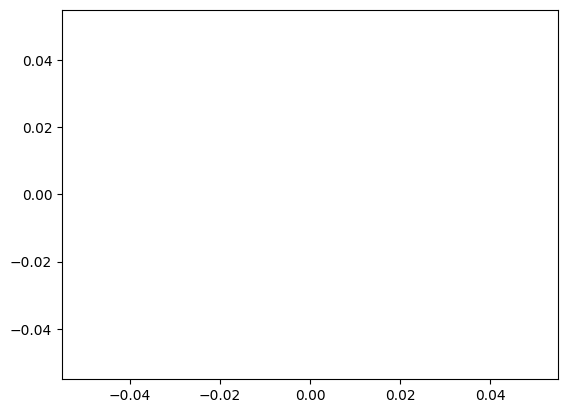

In [247]:
# planner.ts
start = 80
end = 100
t = [t[0] for t in planner.ts][1:][start:end]
plt.scatter(t[:end],prob_thresholds[start:end])
plt.scatter(t,[np.linalg.norm(qob[0][4:] - planner.replan_data.parameters['object_end_position'].reshape(1,3),axis=1)*10 for qob in q_objs_all[start:end]],'r')
t = [t[0:] for t in planner.ts][1:][start:end]
plt.scatter(t,[np.linalg.norm(qob[0:][:,4:] - planner.replan_data.parameters['object_end_position'].reshape(1,3),axis=1)*10 for qob in self.q_obj[1:][start:end]])
# plot first point of each object
# plt.scatter()

In [ ]:
[np.linalg.norm(qob[0:10][:,4:] - planner.replan_data.parameters['object_end_position'].reshape(1,3),axis=1)*10 for qob in self.q_obj[1:][start:]]
np.linalg.norm(self.q_obj[1:][start:][0][0][4:] - planner.replan_data.parameters['object_end_position'].reshape(1,3),axis=1)

In [279]:
bspline_1_col = BSpline(
    planner.replan_data.result["robot_1_control_points"],
    opt_collision.order,
)
bspline_2_col = BSpline(
    planner.replan_data.result["robot_2_control_points"],
    opt_collision.order,
)
print_collision_score_on_samples(10,planner,bspline_1_col,bspline_2_col)

0.0
group_1: -1.09 group_2: -2.48 group_3: -2.96 group_4: -2.39 
group_1: -0.91 group_2: -2.49 group_3: -4.26 group_4: -3.15 

0.1111111111111111
group_1: -1.09 group_2: -2.48 group_3: -2.96 group_4: -2.39 
group_1: -0.91 group_2: -2.49 group_3: -4.26 group_4: -3.15 

0.2222222222222222
group_1: -1.09 group_2: -2.48 group_3: -2.96 group_4: -2.39 
group_1: -0.91 group_2: -2.49 group_3: -4.26 group_4: -3.15 

0.3333333333333333
group_1: -1.09 group_2: -2.48 group_3: -2.96 group_4: -2.39 
group_1: -0.91 group_2: -2.49 group_3: -4.26 group_4: -3.15 

0.4444444444444444
group_1: -1.09 group_2: -2.48 group_3: -2.96 group_4: -2.39 
group_1: -0.91 group_2: -2.49 group_3: -4.26 group_4: -3.15 

0.5555555555555556
group_1: -1.09 group_2: -2.48 group_3: -2.96 group_4: -2.39 
group_1: -0.91 group_2: -2.49 group_3: -4.26 group_4: -3.15 

0.6666666666666666
group_1: -1.09 group_2: -2.48 group_3: -2.96 group_4: -2.39 
group_1: -0.91 group_2: -2.49 group_3: -4.26 group_4: -3.15 

0.7777777777777777
gr

In [464]:
planner.stop_recording_simulation()

41
42


In [ ]:
point_cloud_viz.update()

In [ ]:
plt.plot(point_cloud_viz.point_cloud[:,2])

In [280]:
planner.stop_recording_simulation()

41
42


In [465]:
q_obj[-1]

array([ 0.99955814,  0.02821256,  0.00535502, -0.00767967,  0.00316488,
        0.38208137,  0.27239448])

In [466]:
# planner.ros_handler.move_robots_to_configuration(planner.q_1s[0][0],planner.q_2s[0][0],20)

for i,(q_obj_cp) in enumerate(q_objs_all):
    b_spline = BSpline(q_obj_cp,3)
    q_obj = b_spline.fast_batch_evaluate(np.linspace(0,1,40))
    # meshcat.SetLineSegments('x1',T@vector_origin,T@vector_x,rgba=Rgba(1,0,0,1))
    meshcat.SetLineSegments('/obj_trajectory/'+str(i),q_obj[:-1,4:].T,q_obj[1:,4:].T,)

: 

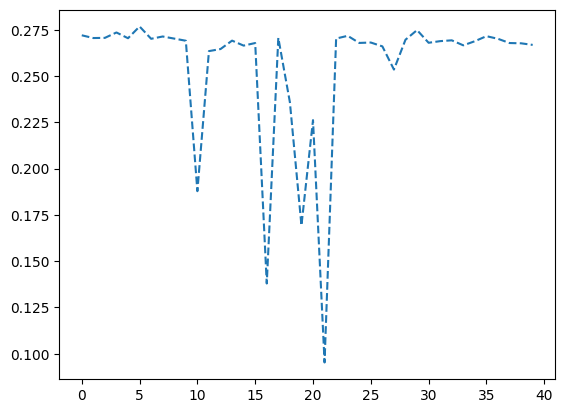

In [451]:
plt.plot((Tss),'--')

In [ ]:
s = np.vstack(actual_q1s)
plt.plot(np.linspace(planner.ts[0][0],planner.ts[-1][-1],s.shape[0])[:200],s[:200])
plt.plot(np.hstack(planner.ts)[:1000],np.vstack(planner.q_1s)[:1000])

In [ ]:
robot_1_collision_checker = torch.compile(robots[0].collision_model.link_collision_modules["all_geometries"].to('cpu'),dynamic=True)
robot_2_collision_checker = torch.compile(robots[1].collision_model.link_collision_modules["all_geometries"].to('cpu'),dynamic=True)
# cc = 
num_eval_points = 20
q_1 = torch.as_tensor(np.column_stack((bspline_1.fast_batch_evaluate(np.linspace(0,1,num_eval_points)), np.zeros((num_eval_points,2)))))
q_2 = torch.as_tensor(np.column_stack((bspline_2.fast_batch_evaluate(np.linspace(0,1,num_eval_points)), np.zeros((num_eval_points,2)))))

obstacle_points = torch.randn(400,3)
obstacle_radii = torch.tensor(0.04, dtype=torch.float32, device='cpu').expand(400, 1)

robot_1_collision_checker(q_1,obstacle_points,obstacle_radii)
robot_2_collision_checker(q_2,obstacle_points,obstacle_radii)

In [ ]:
%%timeit
robot_1_collision_checker(q_1,obstacle_points,obstacle_radii)
robot_2_collision_checker(q_2,obstacle_points,obstacle_radii)

In [ ]:
meshcat.SetProperty("/drake/contact_forces",'visible',False)
meshcat.SetProperty("/drake/proximity",'visible',False)

In [ ]:
print_collision_score_on_samples(10,planner,bspline_1_col,bspline_2_col)
# planner.ros_handler.topic_frequency = 30

In [ ]:

# meshcat.SetPro
# point_cloud_viz.point_cloud

In [ ]:
# planner.ros_handler.ti

In [ ]:
x = np.array(planner.ros_handler.joints_dot_1_filtered_history)
plt.plot(x[-8000:-7500])

In [ ]:
planner.stop_recording_simulation()

In [ ]:

    # print(t)

In [ ]:
q_obj

In [ ]:
plt.plot(Tss)
# planner.stop_recording_simulation()

In [ ]:
meshcat.web_url()

In [ ]:

s_ = np.linspace(0,1,15)
q_1s = self.implemented_trajectory['bspline_1'].fast_batch_evaluate(s_)
q_2s = self.implemented_trajectory['bspline_2'].fast_batch_evaluate(s_)
q_objs = self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_)
# self.check_path_for_collision()

meshcat.StartRecording(frames_per_second=30.0)

for t,q_1,q_2,q_obj in zip(np.linspace(0,1,15),q_1s,q_2s,q_objs):
    
    q_1 = np.concatenate([q_1,np.zeros(2)])
    
    q_2 = np.concatenate([q_2,np.zeros(2)])
    # q_obj = bspline_obj_col.evaluate(s)
    
    # print(g_score_fake_function_repsum.call({'x':np.concatenate([q_obj,q_1,q_2,np.zeros(6)]),'fk_S':opt_data_collision.parameters[opt_info.svm_support_vectors],'A':opt_data_collision.parameters[opt_info.svm_weights]}))
    # print(g_translation)
    viz_helper.set_position('robot_0',q_1)
    viz_helper.set_position('robot_1',q_2)
    viz_helper.set_position('carried_object',q_obj)
    

    viz_helper.diagram_context.SetTime(t)
    # viz_helper.publish()
    viz_helper.publish_diagram()
meshcat.StopRecording()
# print('Success?',opt_collision.optimization_data['debug'].within_bounds())

# print(opt_collision.optimization_data['debug'].result["duration"])
meshcat.PublishRecording()

In [ ]:
planner.stop_recording_simulation()